<a href="https://colab.research.google.com/github/Clarkpriestly/Generative-Adversarial-Network-with-SwinUNeTR-as-encoder-for-Tumor-Segmentation/blob/main/Generative_Adversarial_Network_with_SwinUNeTR_as_encoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#!pip install --upgrade --force-reinstall numpy
#!pip install --upgrade --force-reinstall scipy
!pip install --upgrade --force-reinstall torchio monai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.5/128.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 114.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 117.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243

# Defining the Broilerplate
Broilerplate is the page containing all the packages used in the code

In [1]:
import os
import wandb
import numpy as np
import nibabel as nib
from glob import glob
from tqdm import tqdm
from statistics import mean
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import torchio as tio
from torchio.data import SubjectsLoader, SubjectsDataset

from monai.networks.nets import SwinUNETR
from monai.losses import DiceLoss, DiceCELoss

# Telling python to check whether there is gpu available, if yes, turn that on, else continue using cpu
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.__version__, device

('2.7.0+cu126', device(type='cuda'))

In [2]:
# --- Download Dataset from google drive--- #
!gdown -q 1wEwKrXkXORCooDrH_92FlrTJYZ-0b9CH # BraTS-SSA
!unzip -q ASNR-MICCAI-BraTS2023-SSA-Challenge-TrainingData_V2.zip

In [3]:
# --- Custom DataLoader w/ Torchio --- #
class SegmentationDataset(SubjectsDataset):
    def __init__(self, root_dir: str, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.mri_paths = sorted(glob(os.path.join(root_dir, "**", "*t2f*.nii.gz"), recursive=True))
        self.mask_paths = sorted(glob(os.path.join(root_dir, "**", "*seg.nii.gz"), recursive=True))

        self.subjects = [
            tio.Subject(
                mri=tio.ScalarImage(mri_path),
                mask=tio.LabelMap(mask_path),
            )for mri_path, mask_path in zip(self.mri_paths, self.mask_paths)]

        super().__init__(self.subjects, transform=transform)

transforms = tio.Compose(
    [
        tio.ToCanonical(),
        tio.ZNormalization(),
        tio.Resample((2.4, 2.4, 2.2)),
        tio.RescaleIntensity(percentiles = (0, 99.5), out_min_max=(-1, 1)),# Assignment: Add a RescaleIntensity transform here and clip it to a range betweeen 0% and 99.5%
        # https://torchio.readthedocs.io/transforms/preprocessing.html
        tio.CropOrPad((96, 96, 64)),
    ]
  )

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


torch.Size([2, 1, 96, 96, 64]) torch.Size([2, 1, 96, 96, 64])


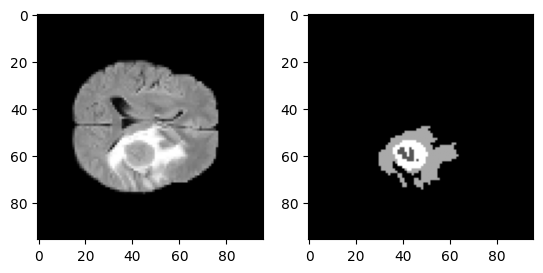

In [4]:
# --- Create and Test DataLoader --- #
dataset = SegmentationDataset(root_dir = 'ASNR-MICCAI-BraTS2023-SSA-Challenge-TrainingData_V2', transform=transforms)
dataloader = SubjectsLoader(dataset, batch_size=2, shuffle=True, num_workers=4)

batch = next(iter(dataloader))
mri_data = batch['mri'][tio.DATA]
mask_data = batch['mask'][tio.DATA]

print(mri_data.shape, mask_data.shape)
plt.subplot(1,2,1)
plt.imshow(mri_data[..., 31][1].squeeze(), cmap='gray')
plt.subplot(1,2,2)
plt.imshow(mask_data[..., 31][1].squeeze(), cmap='gray')

# Defining a Generative Adversarial Network (GAN) with a SwinUNeTR model

In this GAN, we are defining the encoder (GENERATOR) part of the GAN with a SwinUNeTR model on a decoder

In [5]:
class SwinUNETR_Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = SwinUNETR(
            img_size=(96, 96, 64),
            in_channels=1,
            out_channels=1,
            feature_size=48,
            drop_rate=0.0,
            attn_drop_rate=0.0,
            dropout_path_rate=0.0,
            use_checkpoint=True,
            use_v2 = False
        ).to(device)
        #Removing the built-in decoder
        #del self.encoder.decoder

    def forward(self, x):
        return self.encoder(x)

/usr/local/lib/python3.11/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


Output shape: torch.Size([2, 1, 96, 96, 64])


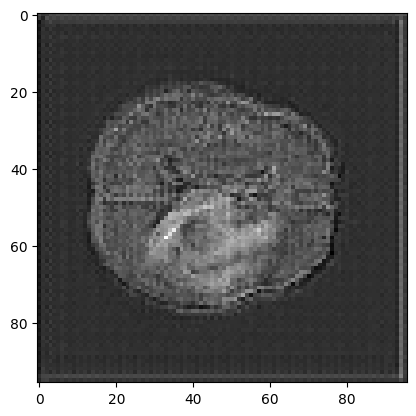

In [10]:
model = SwinUNETR_Generator().to(device)
sample_input = torch.randn(1, 1, 96, 96, 64, device=device)
output = model(mri_data.to(device))

print("Output shape:", output.shape)
plt.imshow(output[..., 32][1].cpu().detach().numpy().squeeze(), cmap = 'gray')

# The Discriminator

In [11]:
class Discriminator3D(nn.Module):
    def __init__(self):
        super(Discriminator3D, self).__init__()
        # Using 2 channels (concatenated input and target)
        self.layer1 = self.conv3d_relu(2, 16, kernel_size=5, cnt=1)
        self.layer2 = self.conv3d_relu(16, 32, pool_size=4)
        self.layer3 = self.conv3d_relu(32, 64, pool_size=2)
        self.layer4 = self.conv3d_relu(64, 128, pool_size=2)
        self.layer5 = self.conv3d_relu(128, 256, pool_size=2)
        self.layer6 = nn.Conv3d(256, 1, kernel_size=1)

    def conv3d_relu(self, in_c, out_c, kernel_size=3, pool_size=None, cnt=2):
        layers = []
        for i in range(cnt):
            if i == 0 and pool_size is not None:
                # Downsample width, height and depth
                layers.append(nn.AvgPool3d(pool_size))

            layers.append(nn.Conv3d(in_c if i == 0 else out_c, out_c, kernel_size, padding=(kernel_size - 1) // 2))
            layers.append(nn.InstanceNorm3d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    def forward(self, x):
        features = []
        x = self.layer1(x)
        features.append(x)
        x = self.layer2(x)
        features.append(x)
        x = self.layer3(x)
        features.append(x)
        x = self.layer4(x)
        features.append(x)
        x = self.layer5(x)
        features.append(x)
        x = self.layer6(x)
        features.append(x)
        return features

# Defining the Training Function

In [12]:
def train_fn(train_dl, G, D, criterion_mse, criterion_mae, optimizer_g, optimizer_d):

    G.train()
    D.train()

    total_loss_g, total_loss_d = [], []

    for i, batch in enumerate(tqdm(train_dl)):
        mri = batch["mri"][tio.DATA].to(device)
        mask = batch["mask"][tio.DATA].to(device)

        # Generator Forward Pass
        generated_mask = G(mri)

        # Discriminator Forward Pass
        fake_pred = D(torch.cat([mri, generated_mask], dim=1))[-1]
        real_pred = D(torch.cat([mri, mask], dim=1))[-1]

        real_label = torch.rand_like(real_pred)
        fake_label = torch.rand_like(fake_pred)

        # Generator Loss & Update
        # Assignment: Introduce a DiceLoss in addition to L1 & MSE
        LAMBDA_L1 = 2.0
        loss_g_gan = criterion_mse(fake_pred, real_label)
        loss_g_l1 = criterion_mae(generated_mask, mask)
        loss_g = loss_g_gan + (loss_g_l1 * LAMBDA_L1)
        loss_function = DiceCELoss(to_onehot_y=False, sigmoid=True)

        optimizer_g.zero_grad()
        loss_g.backward()
        optimizer_g.step()

        # Discriminator Loss & Update
        fake_pred = D(torch.cat([mri, generated_mask.detach()], dim=1))[-1]

        loss_d_fake = criterion_mse(fake_pred, fake_label)
        loss_d_real = criterion_mse(real_pred, real_label)
        loss_d = (loss_d_real + loss_d_fake)

        optimizer_d.zero_grad()
        loss_d.backward()
        optimizer_d.step()

        # Record Losses
        total_loss_g.append(loss_g.item())
        total_loss_d.append(loss_d.item())

    return (mean(total_loss_g), mean(total_loss_d),
            generated_mask.detach().cpu(),
            mask.detach().cpu(),
            mri.detach().cpu())

# Defining the Training Loop

In [13]:
def train_loop(train_dl, G, D, num_epoch, lr=0.0002, betas=(0.5, 0.999)):
    G.to(device)
    D.to(device)

    optimizer_g = torch.optim.Adam(G.parameters(), lr=2e-4, betas=betas)
    optimizer_d = torch.optim.Adam(D.parameters(), lr=1e-5, betas=betas)

    criterion_mae = nn.L1Loss()
    criterion_mse = nn.MSELoss()
    total_loss_d, total_loss_g = [], []
    result = {"G": [], "D": []}

    for e in range(num_epoch):
        print(f"\nEpoch {e+1}/{num_epoch}")
        loss_g, loss_d, fake_img, real_img, input_img, = train_fn(train_dl, G, D,
                                                                  criterion_mse, criterion_mae,
                                                                  optimizer_g, optimizer_d)

        total_loss_d.append(loss_d)
        total_loss_g.append(loss_g)
        result["G"].append(loss_g)
        result["D"].append(loss_d)

        print(f"Generator Loss: {loss_g:.4f}, Discriminator Loss: {loss_d:.4f}")

        wandb.log({
            "Generator Loss": loss_g,
            "Discriminator Loss": loss_d,
            "epoch": e + 1
        })

        if (e + 1) % 10 == 0:
            saving_model(D, G, e)
            save_comparison(real_img, fake_img, input_img, e + 1)

    print("Training completed successfully")
    return G, D

# Comparing the performances of the Generator and the Discriminator
To see which performed best

In [14]:
def save_comparison(real_img, fake_img, input_img, epoch):
    os.makedirs("generated", exist_ok=True)
    real_sample = real_img[0]
    fake_sample = fake_img[0]
    input_sample = input_img[0]

    if real_sample.shape[0] > 1:
        real_sample = real_sample[0].unsqueeze(0)
        fake_sample = fake_sample[0].unsqueeze(0)
        input_sample = input_sample[0].unsqueeze(0)

    real_slice = real_sample[..., 30]
    fake_slice = fake_sample[..., 30]
    input_slice = input_sample[..., 30]

    # Convert to numpy and normalize for better visualization
    def prepare_slice(slice_tensor):
        slice_np = slice_tensor.cpu().detach().numpy().squeeze()
        slice_np = (slice_np - slice_np.min()) / (slice_np.max() - slice_np.min())
        return slice_np

    real_np = prepare_slice(real_slice)
    fake_np = prepare_slice(fake_slice)
    input_np = prepare_slice(input_slice)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    ax1.imshow(input_np, cmap='gray')
    ax1.set_title('Input Image')
    ax1.axis('off')
    ax2.imshow(fake_np, cmap='gray')
    ax2.set_title('Generated Image')
    ax2.axis('off')
    ax3.imshow(real_np, cmap='gray')
    ax3.set_title('Real Image')
    ax3.axis('off')

    plt.suptitle(f'Epoch {epoch}')
    plt.savefig(f'generated/comparison_epoch_{epoch}.png', bbox_inches='tight', dpi=150)
    wandb.log({"Comparison": wandb.Image(plt.gcf(), caption=f"Epoch {epoch}")})

    plt.close()


def saving_model(D, G, e):
    os.makedirs("weight", exist_ok=True)
    torch.save(G.state_dict(), f"weight/G{str(e+1)}.pth")
    torch.save(D.state_dict(), f"weight/D{str(e+1)}.pth")

In [15]:
# Assignment: Create a WANDB account and generate your API Key
WANDB_API_KEY = " "  # ← Replace with your key
wandb.login(key=WANDB_API_KEY)
wandb.init(project="SwinUNeTR BraTS Segmentation")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ireneausnyame7 (ireneausnyame7-university-of-cape-coast) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [16]:
G = SwinUNETR_Generator()
D = Discriminator3D()

EPOCH = 50
trained_G, trained_D = train_loop(dataloader, G, D, EPOCH)

/usr/local/lib/python3.11/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)



Epoch 1/50


  0%|          | 0/30 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 30/30 [01:28<00:00,  2.96s/it]


Generator Loss: 0.4799, Discriminator Loss: 0.3680

Epoch 2/50


100%|██████████| 30/30 [01:25<00:00,  2.85s/it]


...

Generator Loss: 0.1329, Discriminator Loss: 0.1803

Epoch 49/50


100%|██████████| 30/30 [01:21<00:00,  2.72s/it]


Generator Loss: 0.1324, Discriminator Loss: 0.1770

Epoch 50/50


100%|██████████| 30/30 [01:22<00:00,  2.74s/it]


Generator Loss: 0.1290, Discriminator Loss: 0.1736
Training completed successfully


Below are results from the Generative Adversarial Network (GAN) and the comparison between the Generator (i.e SwinUNeTR) and the Discriminator (i.e decoder). We realize that the Generator performed better than the discriminator as if had a lower loss after the 50 epochs.

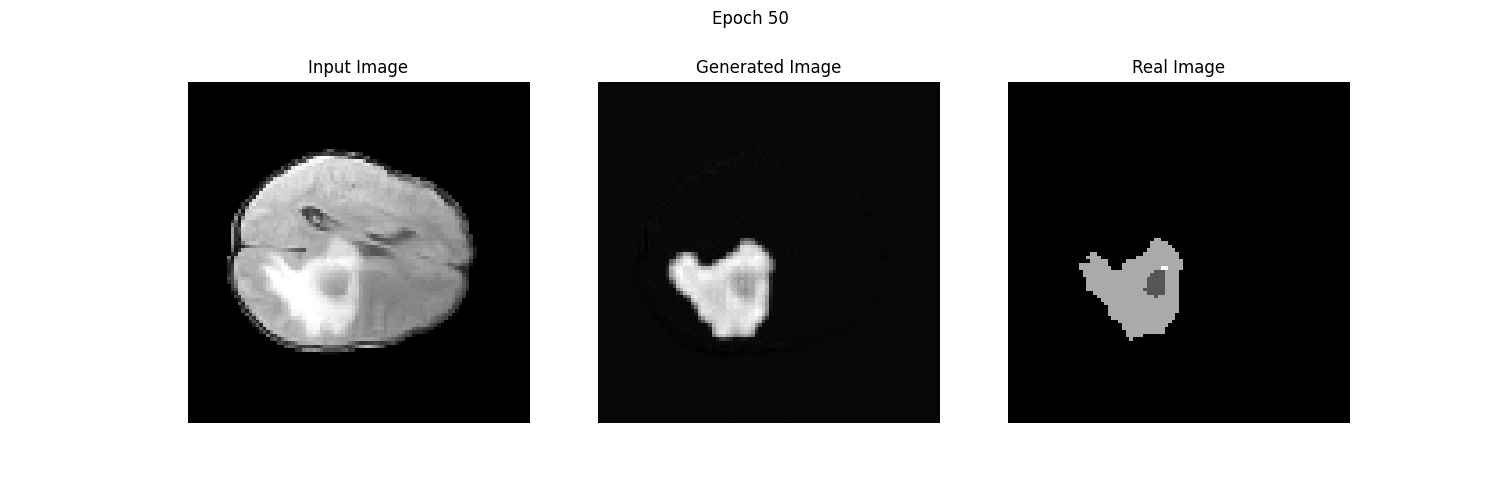

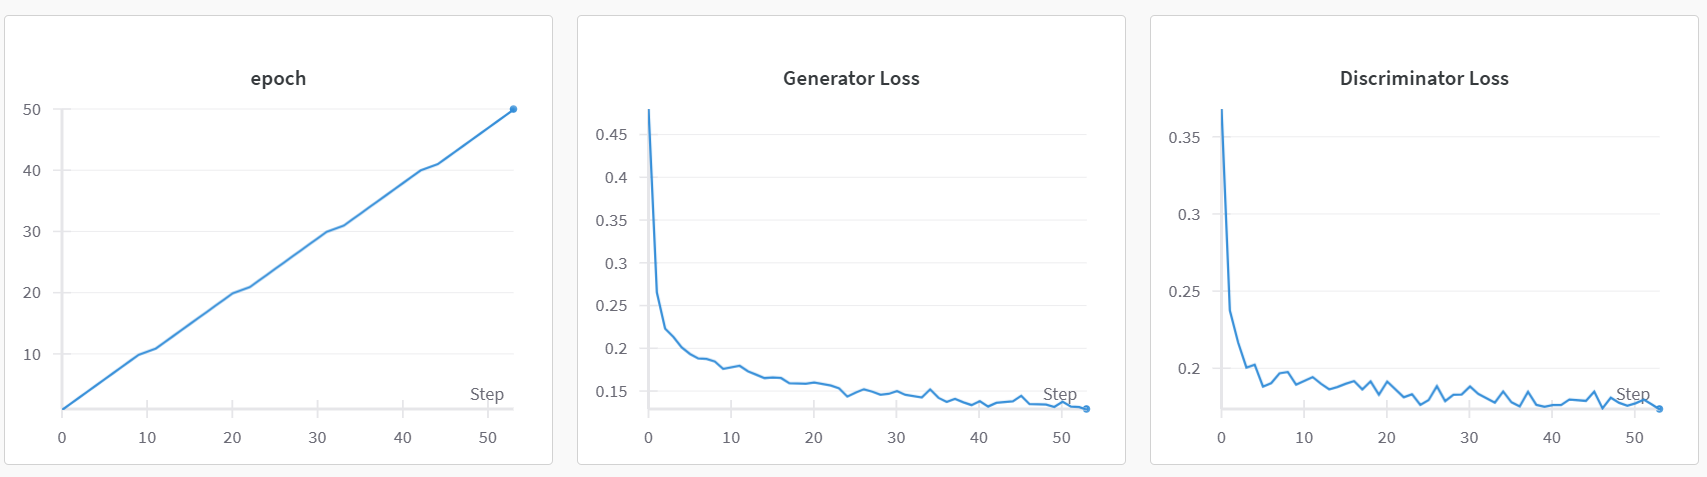

Author: Ireneaus Nyame

Linkedin: www.linkedin.com/in/ireneausnyame

GitHub: